# Noise Mitigation techniques with Iris Dataset
## Part 1: Variational Quantum Classifier (VQC) with Data Reuploading

**Architecture:**
- Encoding: `AngleEmbedding` (RY rotations)
- Ansatz: `StronglyEntanglingLayers`
- Strategy: Data Reuploading (embedding + ansatz repeated `n_layers` times)
- Classification: 1-vs-All × 3 (one per Iris class)

**Backends:**
- Simulator: `default.qubit` (PennyLane)
- Noisy Simulator for training: `qiskit.aer` noise_model
- Real hardware for evaluation: `qiskit.ibmq` via `pennylane-qiskit` plugin


## 1. Imports & Configuration

In [1]:
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility 
SEED = 42
np.random.seed(SEED)

# Circuit hyperparameters
N_QUBITS    = 4   # one qubit per Iris feature
N_LAYERS    = 2   # reuploading depth (embedding + ansatz repeated N_LAYERS times)
N_FEATURES  = 4   # sepal/petal length & width
SHOTS_SIM   = None  # exact statevector on default.qubit
SHOTS_HW    = 100   # finite shots for real / noisy hardware

# Training hyperparameters
LEARNING_RATE = 0.05
N_EPOCHS      = 15
BATCH_SIZE    = 5

# IBM Quantum credentials (fill in before running the hardware section)
IBM_TOKEN    = "humUrPZvu9eOHivSAIeoGOkHDvndpIqSNiZyq6bP-ruZ"

CLASS_NAMES = ["setosa", "versicolor", "virginica"]
print(f"PennyLane version : {qml.__version__}")

PennyLane version : 0.44.1


In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel
from pennylane_qiskit import RemoteDevice
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=IBM_TOKEN
)
backends = service.backends(simulator=False, operational=True)
print([b.name for b in backends])

qiskit_runtime_service._discover_account:WARNING:2026-06-04 20:45:43,227: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-04 20:45:47,259: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-04 20:45:47,260: Loading instance: open-instance, plan: open


['ibm_marrakesh', 'ibm_kingston', 'ibm_fez']


In [3]:
ibm_backend = service.backend("ibm_marrakesh")

qiskit_runtime_service.backends:WARNING:2026-06-04 20:45:49,100: Using instance: open-instance, plan: open


In [47]:
props   = ibm_backend.properties()

gate_names = set(gate.gate for gate in props.gates)
print("Available gates:", gate_names)

Available gates: {'rzz', 'x', 'rz', 'measure', 'rx', 'reset', 'cz', 'id', 'sx'}


In [ ]:
def summarize_errors(errors, label):
    if not errors:
        print(f"{label}: no data")
        return
    arr          = np.array(errors)
    arr_filtered = arr[arr < 1.0]
    print(f"{label}:")
    print(f"  min           : {arr.min():.6f}")
    print(f"  max           : {arr.max():.6f}")
    print(f"  mean          : {arr.mean():.6f}")
    print(f"  mean (filtered): {arr_filtered.mean():.6f}  ({len(arr) - len(arr_filtered)} dead qubit(s) excluded)")

# Single-qubit gate errors (SX gate)
sx_errors = [
    param.value
    for gate in props.gates
    if gate.gate == 'sx'
    for param in gate.parameters
    if param.name == 'gate_error'
]

# Two-qubit gate errors (CZ gate)
tq_errors = [
    param.value
    for gate in props.gates
    if gate.gate == 'cz' and len(gate.qubits) == 2
    for param in gate.parameters
    if param.name == 'gate_error'
]

# Readout errors
ro_errors = [
    param.value
    for qubit in props.qubits
    for param in qubit
    if param.name == 'readout_error'
]

tq_filtered = [e for e in tq_errors if e < 1.0]

print("=" * 40)
summarize_errors(sx_errors, "Single-qubit gate errors (SX)")
print()
summarize_errors(tq_errors, "Two-qubit gate errors (CZ)")
print()
summarize_errors(ro_errors, "Readout errors")
print("=" * 40)

noise_level_PEC = np.mean(tq_filtered)
# print(f"\nSuggested noise_level for PEC : {noise_level_PEC}")

Single-qubit gate errors (SX):
  min           : 0.000115
  max           : 1.000000
  mean          : 0.026093
  mean (filtered): 0.000464  (4 dead qubit(s) excluded)

Two-qubit gate errors (CZ):
  min           : 0.001069
  max           : 1.000000
  mean          : 0.045571
  mean (filtered): 0.006038  (14 dead qubit(s) excluded)

Readout errors:
  min           : 0.003296
  max           : 0.509155
  mean          : 0.031901
  mean (filtered): 0.031901  (0 dead qubit(s) excluded)

Suggested noise_level for PEC : 0.0060383180196619405


## 2. Dataset 1-vs-All preparation

In [4]:
# Load & scale to [0, π] so features map cleanly onto RY rotation angles
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map target integers to names for better visualization
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset preview:")
print(df.head())

Dataset preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


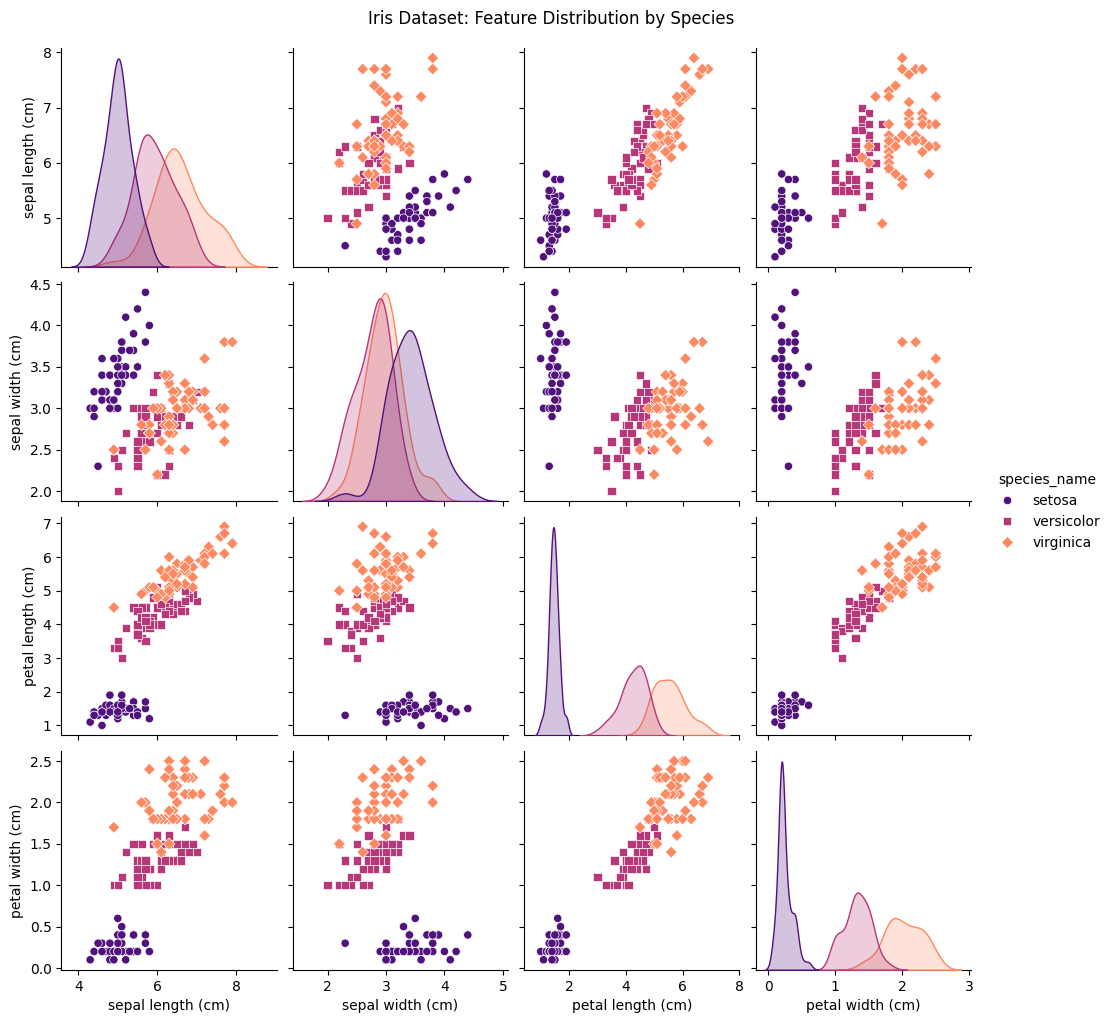

In [5]:
# Select only the feature columns for the pairplot (excluding 'species' and 'species_name')
feature_cols = iris.feature_names 

sns.pairplot(df[feature_cols + ['species_name']], hue='species_name', palette='magma', markers=["o", "s", "D"])
plt.suptitle("Iris Dataset: Feature Distribution by Species", y=1.02)
plt.show()

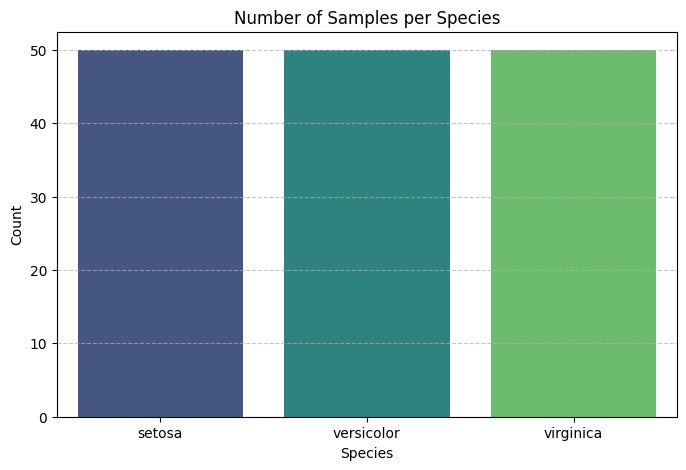

Class counts:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [6]:
# Count the number of samples for each species to ensure a balanced dataset
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='species_name', palette='viridis')

plt.title("Number of Samples per Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print counts for verification
print("Class counts:")
print(df['species_name'].value_counts())

In [7]:
X_raw = iris.data.astype(np.float64)
y_raw = iris.target

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_raw)

# Build one binary dataset per class (1-vs-All)
def make_binary_dataset(X, y, positive_class):
    """
    Convert a multi-class target array into a binary {+1, -1} array.
    The chosen `positive_class` becomes +1; all others become -1.
    Labels are +1 / -1 to match the PauliZ expectation value output.
    """
    y_bin = np.where(y == positive_class, 1, -1).astype(np.float64)
    return X, y_bin

datasets = {}
for class_idx, class_name in enumerate(CLASS_NAMES):
    X_bin, y_bin = make_binary_dataset(X_scaled, y_raw, class_idx)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_bin, y_bin, test_size=0.2, random_state=SEED, stratify=y_bin
    )
    datasets[class_name] = {
        "X_train": X_tr, "y_train": y_tr,
        "X_test" : X_te, "y_test" : y_te,
    }
    pos = int((y_bin == 1).sum())
    print(f"  {class_name:12s} | +1: {pos:3d}  -1: {len(y_bin)-pos:3d} "
          f"| train: {len(y_tr)}  test: {len(y_te)}")

  setosa       | +1:  50  -1: 100 | train: 120  test: 30
  versicolor   | +1:  50  -1: 100 | train: 120  test: 30
  virginica    | +1:  50  -1: 100 | train: 120  test: 30


## 3. Reusable Circuit Function

The same architecture is instantiated for every (class, backend) combination:

Repeat N_LAYERS times  (data reuploading loop) 

AngleEmbedding(x)   — RY on 4 qubits 

StronglyEntanglingLayers(W_l)   

Measure ⟨Z₀⟩  ∈ (−1, +1)


In [8]:
def create_vqc(device_name, n_qubits=N_QUBITS, n_layers=N_LAYERS, **device_kwargs):
    """
    Factory that builds a Variational Quantum Classifier with Data Reuploading.

    The same circuit topology is shared across all 1-vs-All classifiers and
    across both the simulator and real-hardware backends — only the underlying
    PennyLane device changes.

    Architecture (per reuploading layer):
        AngleEmbedding(x)  →  StronglyEntanglingLayers(W_l)
    Repeated `n_layers` times, then measure ⟨Z₀⟩.
    """

    device = qml.device(device_name, wires=n_qubits, **device_kwargs)

    # Weight shape: one (n_qubits × 3) parameter block per reuploading layer
    weight_shape = qml.StronglyEntanglingLayers.shape(
        n_layers=n_layers, n_wires=n_qubits
    )

    @qml.qnode(device, diff_method="best") #With diff_method best it uses Parameter-Shift-Rule (perfect gradients)
    def circuit(inputs, weights):
        """
        Data-reuploading VQC circuit.

        Parameters
        ----------
        inputs  : array, shape (n_features,)
        weights : array, shape (n_layers, n_qubits, 3)
                  Trainable rotation angles for StronglyEntanglingLayers.

        Returns
        -------
        float  — expectation value ⟨Z₀⟩ ∈ (−1, +1)
        """
        for layer_idx in range(n_layers):
            # Encode classical data into quantum amplitudes 
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')

            # Trainable entangling ansatz
            # Each layer applies RZ/RY/RZ + CNOT entanglers across all qubits
            qml.StronglyEntanglingLayers(
                weights[layer_idx * (weight_shape[0] // n_layers) :
                        (layer_idx + 1) * (weight_shape[0] // n_layers)],
                wires=range(n_qubits)
            )

        # Measurement
        # ⟨Z₀⟩ → sign gives predicted class: +1 (positive) or -1 (negative)
        return qml.expval(qml.PauliZ(0))

    return circuit, weight_shape, device

In [9]:
def create_vqc_noisy(device_name, n_qubits=N_QUBITS, n_layers=N_LAYERS, **device_kwargs):
    device = qml.device(device_name, wires=n_qubits, **device_kwargs)
    weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)

    @qml.qnode(device)   # no diff_method — SPSA handles it externally, for faster compilation
    def circuit(inputs, weights):
        for layer_idx in range(n_layers):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            qml.StronglyEntanglingLayers(
                weights[layer_idx * (weight_shape[0] // n_layers) :
                        (layer_idx + 1) * (weight_shape[0] // n_layers)],
                wires=range(n_qubits)
            )
        return qml.expval(qml.PauliZ(0))

    return circuit, weight_shape, device

In [10]:
# Draw Circuit

## 4. Instantiate All Circuits

| Variable | Backend | Class |
|---|---|---|
| `sim_setosa` | `default.qubit` | setosa |
| `sim_versicolor` | `default.qubit` | versicolor |
| `sim_virginica` | `default.qubit` | virginica |
| `hw_setosa` | `qiskit.aer` | setosa |
| `hw_versicolor` | `qiskit.aer` | versicolor |
| `hw_virginica` | `qiskit.aer` | virginica |

In [11]:
# Simulator circuits 
sim_setosa,     weight_shape, _ = create_vqc('default.qubit')
sim_versicolor, weight_shape, _ = create_vqc('default.qubit')
sim_virginica,  weight_shape, _ = create_vqc('default.qubit')

print(f"Simulator circuits ready — weight shape per model: {weight_shape}")

# Real hardware circuits
noise_model = NoiseModel.from_backend(ibm_backend)

hw_setosa, weight_shape, hw_dev = create_vqc_noisy(
    'qiskit.aer', shots=SHOTS_HW, backend='qasm_simulator', noise_model=noise_model
)
hw_versicolor, weight_shape, _ = create_vqc_noisy(
    'qiskit.aer', shots=SHOTS_HW, backend='qasm_simulator', noise_model=noise_model
)
hw_virginica, weight_shape, _ = create_vqc_noisy(
    'qiskit.aer', shots=SHOTS_HW, backend='qasm_simulator', noise_model=noise_model
)
print(f"Noisy simulator ready — noise model from: {ibm_backend.name}")

Simulator circuits ready — weight shape per model: (2, 4, 3)


Noisy simulator ready — noise model from: ibm_marrakesh


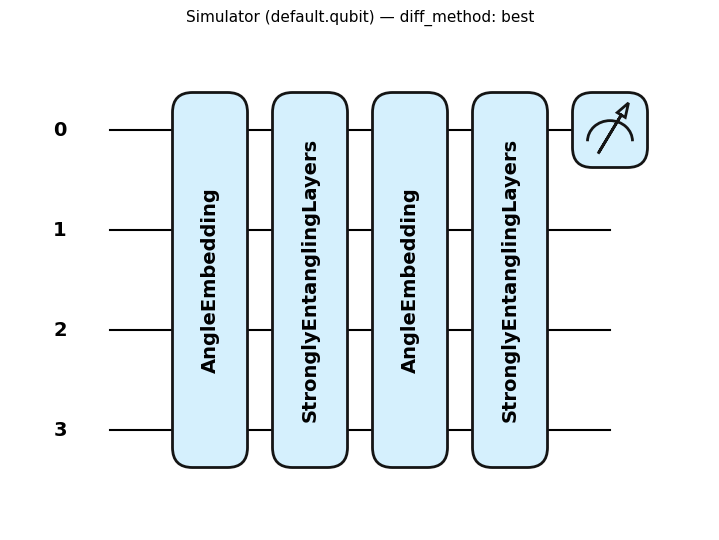

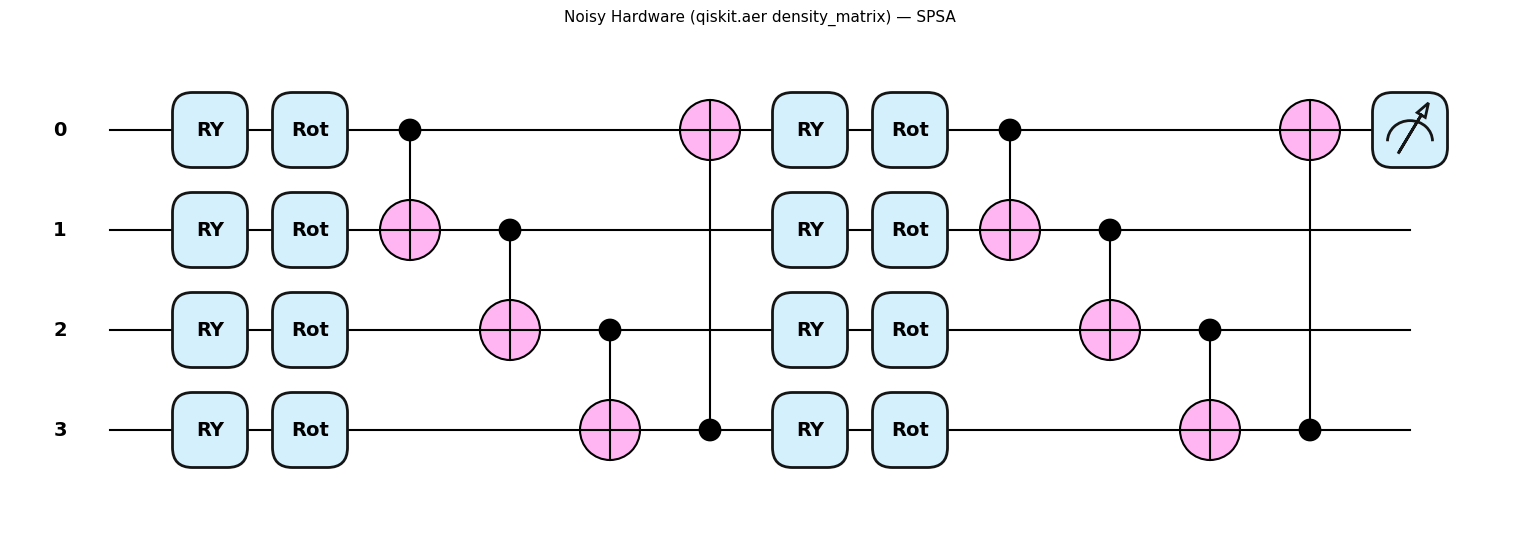

In [12]:
# Draw both circuit versions side by side
dummy_weights = np.zeros(weight_shape)
dummy_input   = np.zeros(N_FEATURES)

# Clean simulator circuit
_, ax = qml.draw_mpl(sim_setosa, decimals=None, style="pennylane")(dummy_input, dummy_weights)
ax.set_title("Simulator (default.qubit) — diff_method: best", fontsize=11)
plt.show()

# Noisy circuit
_, ax = qml.draw_mpl(hw_setosa, decimals=None, style="pennylane")(dummy_input, dummy_weights)
ax.set_title("Noisy Hardware (qiskit.aer density_matrix) — SPSA", fontsize=11)
plt.show()

## 5. Training Loop

In [13]:
def mse_loss(predictions, targets):
    """
    Mean squared error between ⟨Z⟩ predictions and {+1, -1} targets.
    Differentiable through PennyLane's autograd.
    """
    return np.mean((predictions - targets) ** 2)


def train_vqc(
    circuit, weight_shape, X_train, y_train,
    n_epochs=N_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE, label=""
):
    """
    Train a VQC circuit using mini-batch gradient descent with the
    Adam optimiser from PennyLane's autograd backend.

    Parameters
    ----------
    circuit      : QNode returned by create_vqc()
    weight_shape : tuple  — shape of the trainable weight tensor
    X_train      : array, shape (n_samples, n_features)
    y_train      : array, shape (n_samples,)  — values in {+1, -1}
    n_epochs     : int   — number of full passes over training data
    lr           : float — Adam learning rate
    batch_size   : int   — samples per gradient step
    label        : str   — displayed in the progress printout

    Returns
    -------
    weights    : array  — optimised weight tensor
    loss_curve : list   — mean MSE loss recorded after each epoch
    """
    # Initialise weights near zero for stable early training
    weights = np.random.uniform(-np.pi, np.pi, weight_shape, requires_grad=True)
    opt     = qml.AdamOptimizer(stepsize=lr)
    loss_curve = []

    n_samples = len(X_train)

    for epoch in range(n_epochs):
        # Shuffle training data each epoch
        perm     = np.random.permutation(n_samples)
        X_shuf   = X_train[perm]
        y_shuf   = y_train[perm]
        epoch_losses = []

        for start in range(0, n_samples, batch_size):
            X_batch = X_shuf[start : start + batch_size]
            y_batch = y_shuf[start : start + batch_size]

            def batch_cost(w):
                # Vectorised forward pass over the mini-batch
                preds = np.array([circuit(x, w) for x in X_batch])
                return mse_loss(preds, y_batch)

            weights, loss_val = opt.step_and_cost(batch_cost, weights)
            epoch_losses.append(float(loss_val))

        mean_loss = float(np.mean(epoch_losses))
        loss_curve.append(mean_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{label}] epoch {epoch+1:3d}/{n_epochs}  loss: {mean_loss:.4f}")

    return weights, loss_curve

In [14]:
def train_vqc_noisy(circuit, weight_shape, X_train, y_train,
                    n_epochs=N_EPOCHS, label=""):
    weights = np.random.uniform(-np.pi, np.pi, weight_shape, requires_grad=True)
    # maxiter=1 → exactly 2 circuit calls per step, no internal loop
    opt = qml.SPSAOptimizer(maxiter=1)
    loss_curve = []

    for epoch in range(n_epochs):
        # Single cost evaluation over a small random subset (no batching loop)
        idx = np.random.choice(len(X_train), size=10, replace=False)
        X_sub = X_train[idx]
        y_sub = y_train[idx]

        def cost(w):
            preds = np.array([circuit(x, w) for x in X_sub])
            return mse_loss(preds, y_sub)

        weights, loss_val = opt.step_and_cost(cost, weights)
        loss_curve.append(float(loss_val))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{label}] epoch {epoch+1:3d}/{n_epochs}  loss: {float(loss_val):.4f}")

    return weights, loss_curve

### 5.1 Train Simulator Models

In [15]:
sim_results = {}

# Map class name → its simulator circuit
sim_circuits = {
    "setosa"    : sim_setosa,
    "versicolor": sim_versicolor,
    "virginica" : sim_virginica,
}

for class_name, circuit in sim_circuits.items():
    print(f"\n{'─'*50}")
    print(f" Training  [simulator]  1-vs-All: {class_name}")
    print(f"{'─'*50}")
    d = datasets[class_name]
    weights, loss_curve = train_vqc(
        circuit, weight_shape,
        d["X_train"], d["y_train"],
        label=f"sim/{class_name}"
    )
    sim_results[class_name] = {"weights": weights, "loss_curve": loss_curve}


──────────────────────────────────────────────────
 Training  [simulator]  1-vs-All: setosa
──────────────────────────────────────────────────
  [sim/setosa] epoch   1/15  loss: 0.5576
  [sim/setosa] epoch   5/15  loss: 0.1604
  [sim/setosa] epoch  10/15  loss: 0.1453
  [sim/setosa] epoch  15/15  loss: 0.1472

──────────────────────────────────────────────────
 Training  [simulator]  1-vs-All: versicolor
──────────────────────────────────────────────────
  [sim/versicolor] epoch   1/15  loss: 0.6326
  [sim/versicolor] epoch   5/15  loss: 0.3801
  [sim/versicolor] epoch  10/15  loss: 0.2424
  [sim/versicolor] epoch  15/15  loss: 0.2335

──────────────────────────────────────────────────
 Training  [simulator]  1-vs-All: virginica
──────────────────────────────────────────────────
  [sim/virginica] epoch   1/15  loss: 0.5901
  [sim/virginica] epoch   5/15  loss: 0.2961
  [sim/virginica] epoch  10/15  loss: 0.2818
  [sim/virginica] epoch  15/15  loss: 0.3094


### 5.2 Train Hardware (Aer / IBM) Models

In [16]:
hw_results = {}
hw_circuits = {
    "setosa"    : hw_setosa,
    "versicolor": hw_versicolor,
    "virginica" : hw_virginica,
}

for class_name, circuit in hw_circuits.items():
    print(f"\n{'─'*50}")
    print(f" Training  [hardware]   1-vs-All: {class_name}")
    print(f"{'─'*50}")
    d = datasets[class_name]
    weights, loss_curve = train_vqc_noisy(
        circuit, weight_shape,
        d["X_train"], d["y_train"],
        label=f"hw/{class_name}"
    )
    hw_results[class_name] = {"weights": weights, "loss_curve": loss_curve}


──────────────────────────────────────────────────
 Training  [hardware]   1-vs-All: setosa
──────────────────────────────────────────────────
  [hw/setosa] epoch   1/15  loss: 0.9102
  [hw/setosa] epoch   5/15  loss: 0.8520
  [hw/setosa] epoch  10/15  loss: 0.8593
  [hw/setosa] epoch  15/15  loss: 0.8644

──────────────────────────────────────────────────
 Training  [hardware]   1-vs-All: versicolor
──────────────────────────────────────────────────
  [hw/versicolor] epoch   1/15  loss: 0.9548
  [hw/versicolor] epoch   5/15  loss: 0.7468
  [hw/versicolor] epoch  10/15  loss: 1.0777
  [hw/versicolor] epoch  15/15  loss: 0.7570

──────────────────────────────────────────────────
 Training  [hardware]   1-vs-All: virginica
──────────────────────────────────────────────────
  [hw/virginica] epoch   1/15  loss: 1.1273
  [hw/virginica] epoch   5/15  loss: 0.9352
  [hw/virginica] epoch  10/15  loss: 0.9728
  [hw/virginica] epoch  15/15  loss: 1.0407


## 6. Evaluation

In [17]:
def predict_proba(circuit, weights, X):
    """
    Run the trained circuit over dataset X.
    Returns raw ⟨Z⟩ scores ∈ (−1, +1) — higher = more likely positive class.
    """
    return np.array([float(circuit(x, weights)) for x in X])


def predict_binary(circuit, weights, X, threshold=0.0):
    """
    Convert ⟨Z⟩ scores to {+1, -1} hard labels.
    Threshold = 0 corresponds to the decision boundary at ⟨Z⟩ = 0.
    """
    scores = predict_proba(circuit, weights, X)
    return np.where(scores >= threshold, 1, -1).astype(int)


def compute_metrics(y_true, y_pred, class_name):
    """
    Compute classification metrics for a binary 1-vs-All classifier.
    Returns a dict with accuracy, precision, recall, and F1-score.
    """
    return {
        "class"    : class_name,
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

In [18]:
# Evaluation: all 3 conditions
# Condition 1: trained clean sim   → evaluated on clean sim
# Condition 2: trained clean sim   → evaluated on noisy hw
# Condition 3: trained noisy hw    → evaluated on noisy hw

predictions_cache = {}
metrics_rows = []

for class_name in CLASS_NAMES:
    d = datasets[class_name]
    y_true = d["y_test"].astype(int)

    # Condition 1 — clean weights, clean circuit
    y_pred = predict_binary(sim_circuits[class_name],
                            sim_results[class_name]["weights"],
                            d["X_test"])
    m = compute_metrics(y_true, y_pred, class_name)
    m["condition"] = "sim_weights → sim_eval"
    metrics_rows.append(m)

    # Condition 2 — clean weights, noisy circuit
    y_pred = predict_binary(hw_circuits[class_name],
                            sim_results[class_name]["weights"],
                            d["X_test"])
    m = compute_metrics(y_true, y_pred, class_name)
    m["condition"] = "sim_weights → noisy_eval"
    metrics_rows.append(m)

    # Condition 3 — noisy weights, noisy circuit
    y_pred = predict_binary(hw_circuits[class_name],
                            hw_results[class_name]["weights"],
                            d["X_test"])
    m = compute_metrics(y_true, y_pred, class_name)
    m["condition"] = "noisy_weights → noisy_eval"
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)[["condition", "class", "accuracy", "precision", "recall", "f1"]]
metrics_df = metrics_df.sort_values(["class", "condition"]).reset_index(drop=True)

pd.set_option('display.float_format', '{:.3f}'.format)
print("\n" + "="*80)
print(" Metrics: Clean Sim vs Noisy Eval vs Noisy Train+Eval")
print("="*80)
print(metrics_df.to_string(index=False))


 Metrics: Clean Sim vs Noisy Eval vs Noisy Train+Eval
                 condition      class  accuracy  precision  recall    f1
noisy_weights → noisy_eval     setosa     0.667      0.500   0.900 0.643
  sim_weights → noisy_eval     setosa     1.000      1.000   1.000 1.000
    sim_weights → sim_eval     setosa     1.000      1.000   1.000 1.000
noisy_weights → noisy_eval versicolor     0.700      0.526   1.000 0.690
  sim_weights → noisy_eval versicolor     0.933      0.900   0.900 0.900
    sim_weights → sim_eval versicolor     0.933      0.900   0.900 0.900
noisy_weights → noisy_eval  virginica     0.500      0.391   0.900 0.545
  sim_weights → noisy_eval  virginica     0.933      1.000   0.800 0.889
    sim_weights → sim_eval  virginica     0.900      1.000   0.700 0.824


## 7. Visualisations

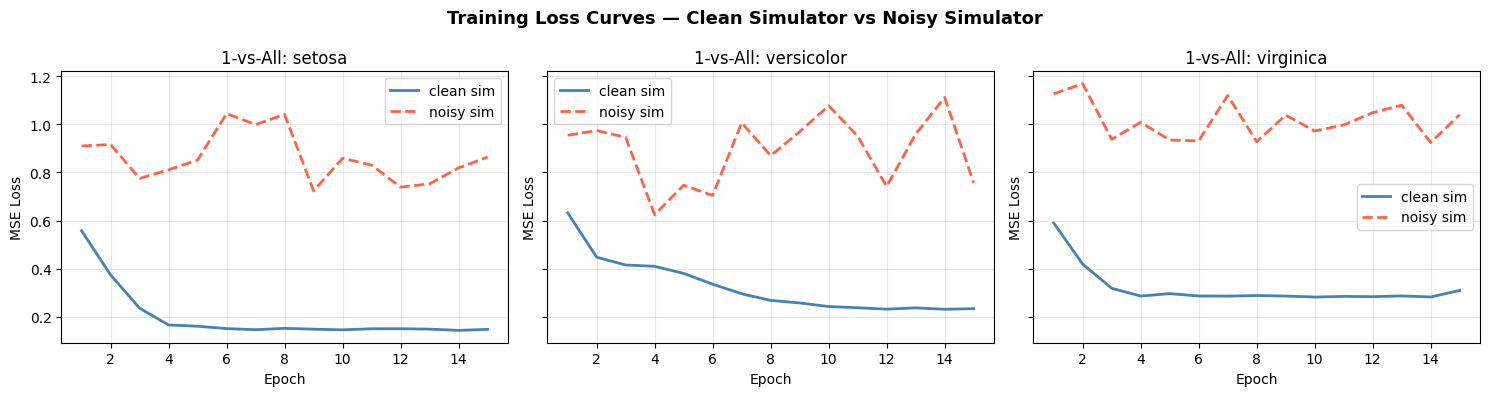

In [19]:
# 7.1 Loss curves — sim vs noisy training
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Training Loss Curves — Clean Simulator vs Noisy Simulator", fontsize=13, fontweight='bold')

for ax, class_name in zip(axes, CLASS_NAMES):
    ax.plot(range(1, len(sim_results[class_name]["loss_curve"]) + 1),
            sim_results[class_name]["loss_curve"],
            label='clean sim', linewidth=2, color='steelblue')
    ax.plot(range(1, len(hw_results[class_name]["loss_curve"]) + 1),
            hw_results[class_name]["loss_curve"],
            label='noisy sim', linewidth=2, color='tomato', linestyle='--')
    ax.set_title(f"1-vs-All: {class_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

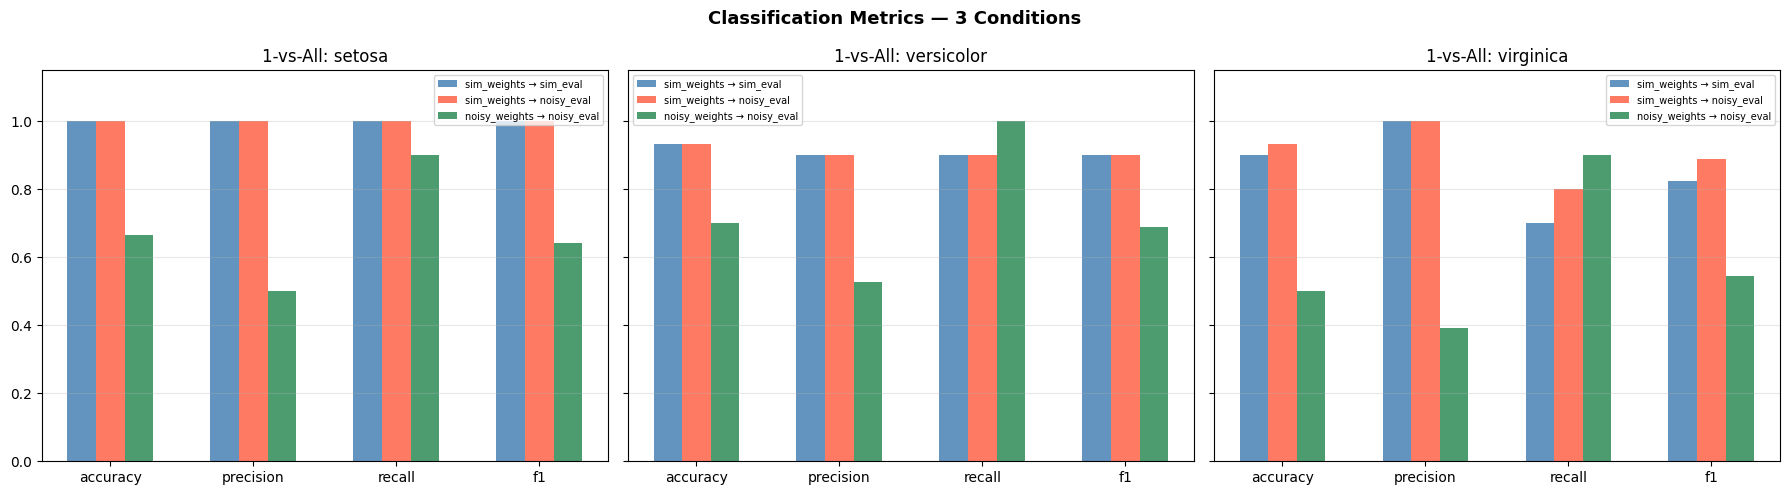

In [20]:
# 7.2 Metrics bar chart — 3 conditions per class
metric_cols = ["accuracy", "precision", "recall", "f1"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Classification Metrics — 3 Conditions", fontsize=13, fontweight='bold')

bar_w = 0.2
conditions = [
    ("sim_weights → sim_eval",   "steelblue", -bar_w),
    ("sim_weights → noisy_eval", "tomato",     0.0),
    ("noisy_weights → noisy_eval","seagreen",  bar_w),
]
x = np.arange(len(metric_cols))

for ax, class_name in zip(axes, CLASS_NAMES):
    for label, color, offset in conditions:
        row = metrics_df[(metrics_df["class"] == class_name) &
                         (metrics_df["condition"] == label)].iloc[0]
        vals = [row[m] for m in metric_cols]
        ax.bar(x + offset, vals, width=bar_w, label=label, color=color, alpha=0.85)

    ax.set_title(f"1-vs-All: {class_name}")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_cols)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

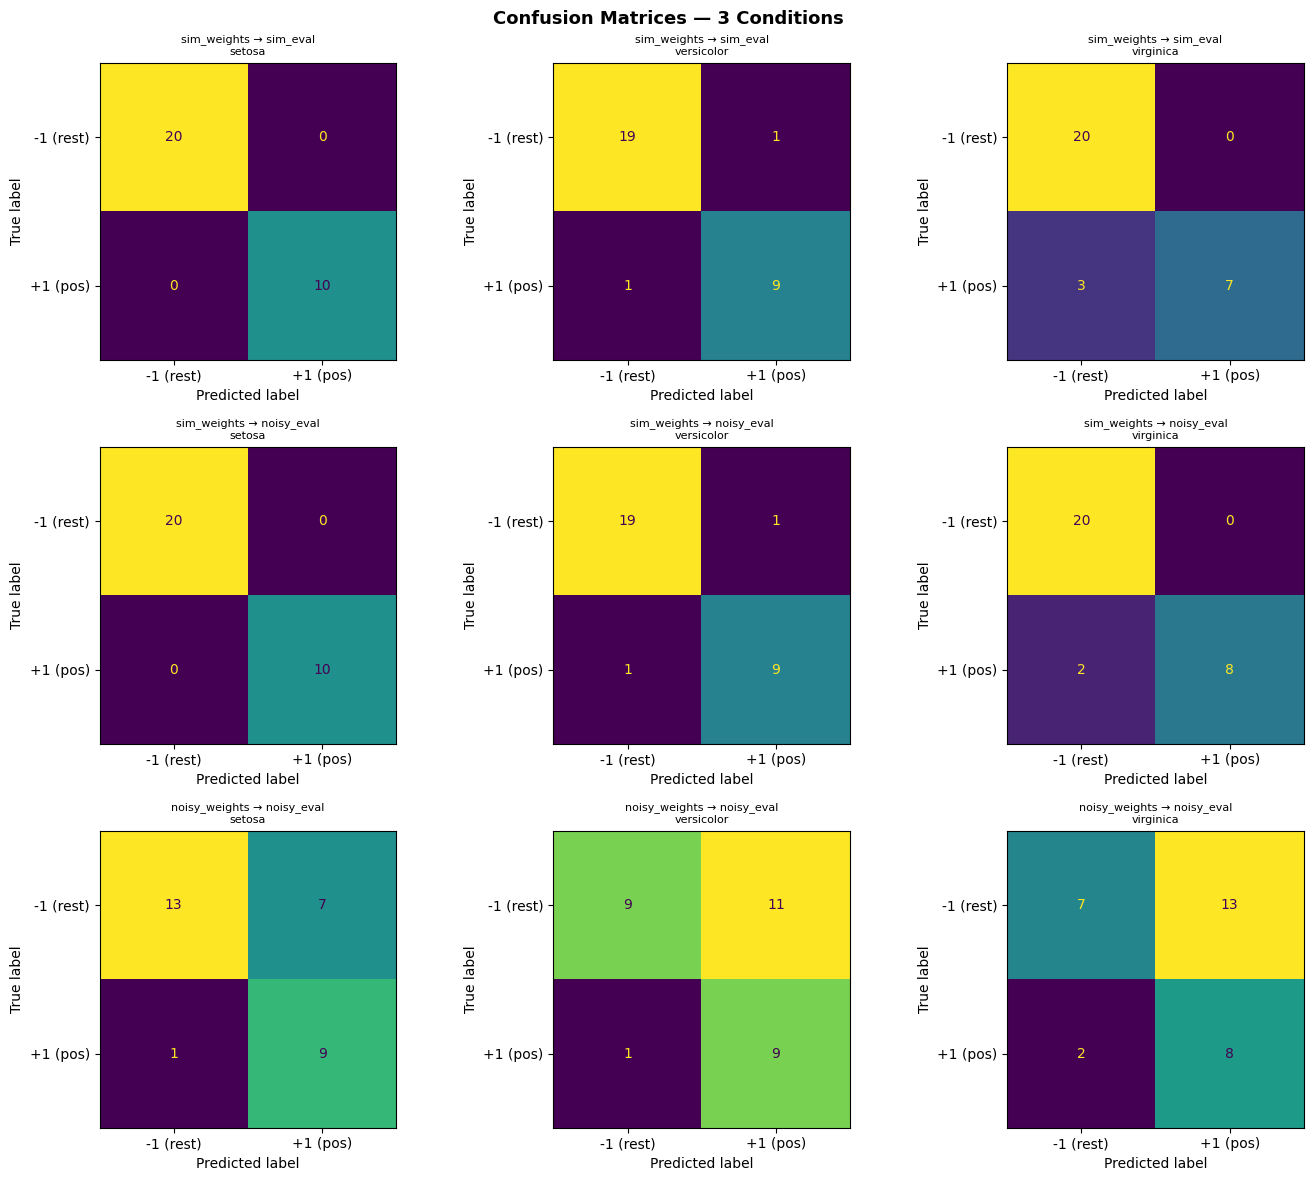

In [21]:
# 7.3 Confusion matrices — 3 rows × 3 cols
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle("Confusion Matrices — 3 Conditions", fontsize=13, fontweight='bold')

conditions_cm = [
    ("sim_weights → sim_eval",    sim_circuits, sim_results),
    ("sim_weights → noisy_eval",  hw_circuits,  sim_results),
    ("noisy_weights → noisy_eval",hw_circuits,  hw_results),
]

for col, class_name in enumerate(CLASS_NAMES):
    d = datasets[class_name]
    y_true = d["y_test"].astype(int)

    for row, (label, circuit_dict, result_dict) in enumerate(conditions_cm):
        y_pred = predict_binary(circuit_dict[class_name],
                                result_dict[class_name]["weights"],
                                d["X_test"])
        cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["-1 (rest)", "+1 (pos)"])
        disp.plot(ax=axes[row][col], colorbar=False)
        axes[row][col].set_title(f"{label}\n{class_name}", fontsize=8)

plt.tight_layout()
plt.show()

As the noisy and clean evaluation have almost the same results in the perfect simulated weights, it means that the noise of the circuit itself is very low (is a very short circuit), so applying anti-noise techniques makes no sense in the perfect weights.

We will apply different techniques to try to improve the evaluation using the noisy weights

# 8. Anti-Noise Techniques

In [22]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit.quantum_info import SparsePauliOp
from mitiq import zne, pec
from mitiq.zne.scaling import fold_gates_at_random, fold_global
from mitiq.zne.inference import RichardsonFactory, LinearFactory
import mthree

In [23]:
def build_qiskit_vqc(weights, inputs, n_qubits=N_QUBITS, n_layers=N_LAYERS):
    """
    Reconstruct the VQC as a native Qiskit circuit using the exact gate
    decomposition that PennyLane generates:
      - AngleEmbedding  → RY(x_i) on each qubit
      - StronglyEntanglingLayers → Rot(a,b,c) + CNOTs with range-based pattern
        range per layer: (l % (n_qubits-1)) + 1
        layer 0: range=1 → CNOTs 0→1, 1→2, 2→3, 3→0
        layer 1: range=2 → CNOTs 0→2, 1→3, 2→0, 3→1
    Weights shape: (n_layers, n_qubits, 3) — matches PennyLane's weight_shape.
    """
    qc = QuantumCircuit(n_qubits)
    w  = np.array(weights).reshape(n_layers, n_qubits, 3)

    # Compute CNOT ranges per layer — same formula as PennyLane default
    ranges = [(l % (n_qubits - 1)) + 1 for l in range(n_layers)]

    for layer_idx in range(n_layers):
        # AngleEmbedding — RY(x_i) on qubit i
        for qubit, angle in enumerate(inputs):
            qc.ry(float(angle), qubit)

        # Rot(a, b, c) = RZ(a) RY(b) RZ(c) on each qubit
        for qubit in range(n_qubits):
            qc.rz(float(w[layer_idx, qubit, 0]), qubit)
            qc.ry(float(w[layer_idx, qubit, 1]), qubit)
            qc.rz(float(w[layer_idx, qubit, 2]), qubit)

        # CNOT entanglers with range r for this layer
        r = ranges[layer_idx]
        for qubit in range(n_qubits):
            qc.cx(qubit, (qubit + r) % n_qubits)

    return qc

In [24]:
observable = SparsePauliOp("Z" + "I" * (N_QUBITS - 1))  # Z on qubit 0

def noisy_executor(qc):
    """
    Run a Qiskit circuit on the noisy Aer backend and return ⟨Z₀⟩.
    mitiq calls this internally when applying mitigation transforms.
    Uses EstimatorV2 API compatible with qiskit-aer >= 0.13.
    """
    estimator = AerEstimator()
    estimator.options.noise_model = noise_model
    estimator.options.shots = SHOTS_HW
    pub    = (qc, observable)
    result = estimator.run([pub]).result()
    return float(result[0].data.evs)

In [25]:
# Baseline: noisy eval, no mitigation
def predict_noisy_baseline(weights, X):
    """
    Evaluate on the noisy Aer backend without any mitigation.
    This is the degraded baseline that the anti-noise techniques aim to improve.
    """
    scores = []
    for x in X:
        qc = build_qiskit_vqc(weights, x)
        scores.append(noisy_executor(qc))
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)

In [ ]:
# ZNE — Zero Noise Extrapolation (Richardson)
def predict_zne(weights, X):
    """
    ZNE with Richardson extrapolation at scale factors [1, 2, 3].
    Uses global circuit folding to amplify noise: the full circuit is
    replaced by C · C† · C at scale 3.
    mitiq extrapolates the 3 noisy expectation values back to zero noise.
    """
    factory = RichardsonFactory(scale_factors=[1, 2, 3])
    scores  = []
    for x in X:
        qc        = build_qiskit_vqc(weights, x)
        mitigated = zne.execute_with_zne(
            qc,
            executor=noisy_executor,
            factory=factory,
            scale_noise=fold_global,
        )
        scores.append(mitigated)
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


# Digital ZNE — gate folding (hardware-friendly)
def predict_digital_zne(weights, X):
    """
    Digital ZNE with random gate folding (G → G G† G) and linear extrapolation.
    Gate folding is hardware-friendly — amplifies noise without pulse-level access.
    LinearFactory is more stable than Richardson for noisy estimates.
    """
    factory = LinearFactory(scale_factors=[1, 2, 3])
    scores  = []
    for x in X:
        qc        = build_qiskit_vqc(weights, x)
        mitigated = zne.execute_with_zne(
            qc,
            executor=noisy_executor,
            factory=factory,
            scale_noise=fold_gates_at_random,
        )
        scores.append(mitigated)
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


# MEM — Measurement Error Mitigation
def build_mem_mitigator(n_qubits=N_QUBITS):
    """
    Calibrate mthree by running 2^n_qubits calibration circuits on the noisy
    backend. Builds a calibration matrix that maps ideal bitstrings to noisy
    ones; its inverse is used to correct measurement distributions at inference.
    """
    backend_aer = AerSimulator(noise_model=noise_model)
    mit         = mthree.M3Mitigation(backend_aer)
    mit.cals_from_system(range(n_qubits), shots=SHOTS_HW)
    return mit


def predict_mem(weights, X, mitigator, n_qubits=N_QUBITS):
    """
    Run the noisy circuit, collect raw measurement counts, apply mthree
    correction to get a quasi-probability distribution, then compute ⟨Z₀⟩
    from the corrected distribution.
    Z₀ eigenvalue: +1 if qubit 0 measured as |0⟩, -1 if measured as |1⟩.
    In Qiskit bitstring ordering the rightmost bit is qubit 0.
    """
    backend_aer = AerSimulator(noise_model=noise_model)
    scores      = []

    for x in X:
        qc = build_qiskit_vqc(weights, x)
        qc_meas = qc.copy()
        qc_meas.measure_all()

        raw_counts = backend_aer.run(qc_meas, shots=SHOTS_HW).result().get_counts()
        quasi_dist = mitigator.apply_correction(raw_counts, range(n_qubits))

        # Rightmost character in Qiskit bitstring = qubit 0
        expval = sum(
            prob * (1 if bitstring[-1] == '0' else -1)
            for bitstring, prob in quasi_dist.items()
        )
        scores.append(expval)

    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)


# PEC — Probabilistic Error Cancellation
def predict_pec(weights, X, noise_level_PEC, num_samples=30):
    """
    PEC with local depolarizing noise representations.
    Learns quasi-probability representations of each gate under the noise model,
    then estimates ⟨Z₀⟩ via Monte Carlo sampling over noisy circuit variants.
    num_samples=30 balances variance vs circuit calls (30 × n_test calls per class).
    Fallback to noisy baseline if representation learning fails.
    """
    scores = []
    for x in X:
        qc = build_qiskit_vqc(weights, x)
        try:
            reps = pec.represent_operations_in_circuit_with_local_depolarizing_noise(
                qc, noise_level=noise_level_PEC
            )
            mitigated = pec.execute_with_pec(
                qc,
                executor=noisy_executor,
                representations=reps,
                num_samples=num_samples,
            )
            
        except Exception as e:
            print(f"  PEC fallback ({e.__class__.__name__}): using noisy baseline")
            mitigated = noisy_executor(qc)
        scores.append(mitigated)
    return np.where(np.array(scores) >= 0.0, 1, -1).astype(int)

In [ ]:
# Calibrate MEM once (reused across all classes)
print("Calibrating MEM mitigator...")
mem_mitigator = build_mem_mitigator()
print("MEM calibration done.\n")

# Run all techniques on noisy weights
techniques = {
    "baseline"    : lambda w, X: predict_noisy_baseline(w, X),
    "ZNE"         : lambda w, X: predict_zne(w, X),
    "Digital_ZNE" : lambda w, X: predict_digital_zne(w, X),
    "MEM"         : lambda w, X: predict_mem(w, X, mem_mitigator),
    "PEC"         : lambda w, X: predict_pec(w, X, noise_level_PEC),
}

mitigation_rows = []

for technique_name, predict_fn in techniques.items():
    print(f"\n{'─'*50}")
    print(f" Technique: {technique_name}")
    print(f"{'─'*50}")
    for class_name in CLASS_NAMES:
        d       = datasets[class_name]
        weights = hw_results[class_name]["weights"]   # noisy SPSA weights
        y_pred  = predict_fn(weights, d["X_test"])
        m       = compute_metrics(d["y_test"].astype(int), y_pred, class_name)
        m["technique"] = technique_name
        mitigation_rows.append(m)
        print(f"  {class_name:12s}  acc={m['accuracy']:.3f}  f1={m['f1']:.3f}")

mitigation_df = pd.DataFrame(mitigation_rows)[
    ["technique", "class", "accuracy", "precision", "recall", "f1"]
]

pd.set_option('display.float_format', '{:.3f}'.format)
print("\n" + "="*75)
print(" Anti-noise Techniques — Noisy Weights")
print("="*75)
print(mitigation_df.to_string(index=False))

Calibrating MEM mitigator...
MEM calibration done.


──────────────────────────────────────────────────
 Technique: baseline
──────────────────────────────────────────────────
  setosa        acc=0.900  f1=0.857
  versicolor    acc=0.533  f1=0.125
  virginica     acc=0.533  f1=0.000

──────────────────────────────────────────────────
 Technique: ZNE
──────────────────────────────────────────────────
  setosa        acc=0.900  f1=0.857
  versicolor    acc=0.533  f1=0.125
  virginica     acc=0.533  f1=0.000

──────────────────────────────────────────────────
 Technique: Digital_ZNE
──────────────────────────────────────────────────
  setosa        acc=0.900  f1=0.857
  versicolor    acc=0.533  f1=0.125
  virginica     acc=0.533  f1=0.000

──────────────────────────────────────────────────
 Technique: MEM
──────────────────────────────────────────────────
  setosa        acc=0.500  f1=0.400
  versicolor    acc=0.433  f1=0.105
  virginica     acc=0.600  f1=0.250

──────────────────────────

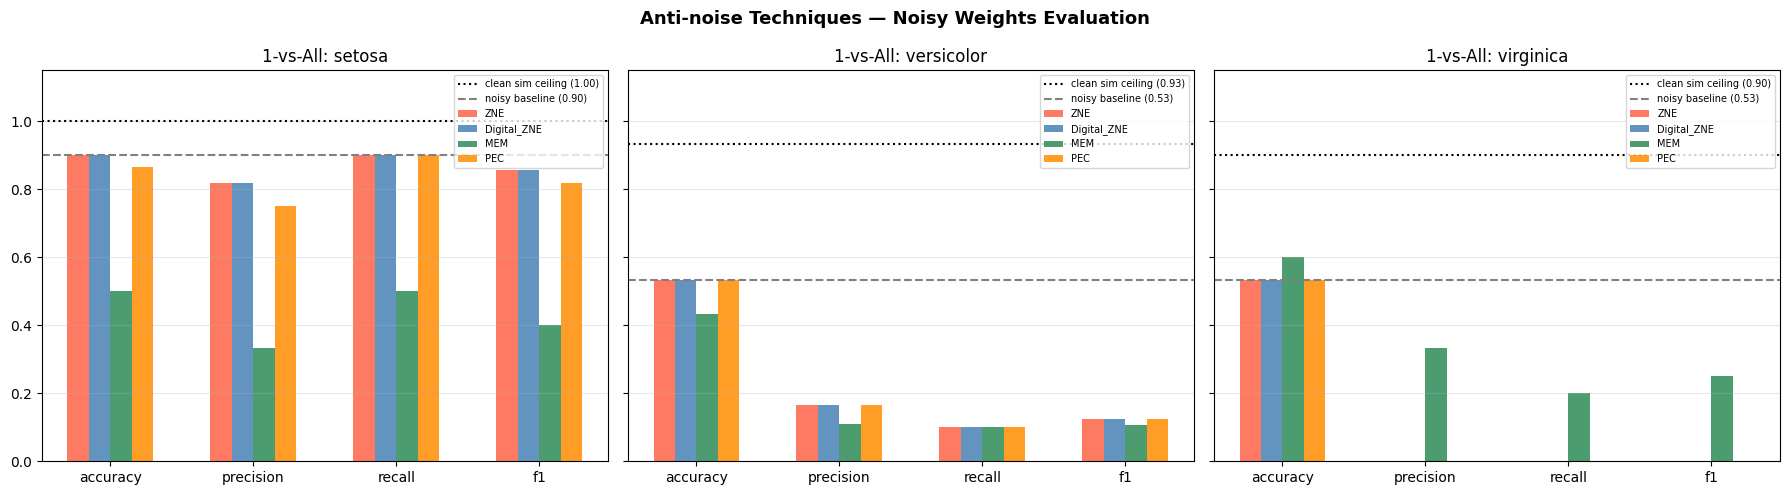

In [34]:
# Visualisation
metric_cols     = ["accuracy", "precision", "recall", "f1"]
technique_names = [t for t in techniques.keys() if t != "baseline"]
colors          = ["tomato", "steelblue", "seagreen", "darkorange"]
bar_w           = 0.15
x               = np.arange(len(metric_cols))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Anti-noise Techniques — Noisy Weights Evaluation", fontsize=13, fontweight='bold')

for ax, class_name in zip(axes, CLASS_NAMES):
    for i, (tech, color) in enumerate(zip(technique_names, colors)):
        offset = (i - len(technique_names) / 2) * bar_w + bar_w / 2
        row    = mitigation_df[(mitigation_df["class"] == class_name) &
                               (mitigation_df["technique"] == tech)].iloc[0]
        vals   = [row[m] for m in metric_cols]
        ax.bar(x + offset, vals, width=bar_w, label=tech, color=color, alpha=0.85)

    # Ceiling 1 — clean simulator (upper bound)
    clean_acc = metrics_df[
        (metrics_df["class"] == class_name) &
        (metrics_df["condition"] == "sim_weights → sim_eval")
    ]["accuracy"].values[0]
    ax.axhline(clean_acc, color='black', linestyle=':', linewidth=1.5,
               label=f'clean sim ceiling ({clean_acc:.2f})')

    # Ceiling 2 — noisy baseline (lower bound, what mitigation must beat)
    baseline_acc = mitigation_df[
        (mitigation_df["class"] == class_name) &
        (mitigation_df["technique"] == "baseline")
    ]["accuracy"].values[0]
    ax.axhline(baseline_acc, color='gray', linestyle='--', linewidth=1.5,
               label=f'noisy baseline ({baseline_acc:.2f})')

    ax.set_title(f"1-vs-All: {class_name}")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_cols)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()